### Modélisation : Dans cette phase finale, nous entrainerons nos modèles et identifierons celui qui nous donne la meilleure performance à partir des métriques.

In [1]:
# Importating necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint, uniform

In [2]:
# Loading the two processed dataset
data_lin= pd.read_csv("../data/processed/smart-city-traffic-stress-index-dataset_clean_lin.csv")
data_boost= pd.read_csv("../data/processed/smart-city-traffic-stress-index-dataset_clean_boost.csv")

In [3]:
# Checking the dataset data_lin
print("data_lin   :", data_lin.shape,   "| colonnes :", data_lin.columns.tolist())

data_lin   : (50000, 4) | colonnes : ['road_quality_score', 'stress_index', 'driver_experience_encoded', 'congestion_score']


In [4]:
# Checking the dataset data_boost
print("data_boost :", data_boost.shape, "| colonnes :", data_boost.columns.tolist())

data_boost : (50000, 9) | colonnes : ['avg_speed', 'road_quality_score', 'stress_index', 'driver_experience_encoded', 'weather_Foggy', 'weather_Hot', 'weather_Rainy', 'congestion_score', 'horn_density']


In [5]:
# Separating features and target
X_lin = data_lin.drop(columns=['stress_index'])
X_boost = data_boost.drop(columns=['stress_index'])
y_lin = data_lin['stress_index']
y_boost = data_boost['stress_index'] 

In [6]:
# Split the data in train and test parts
X_train_lin,   X_test_lin,   y_train_lin,   y_test_lin   = train_test_split(X_lin,   y_lin,   test_size=0.2, random_state=42)
X_train_boost, X_test_boost, y_train_boost, y_test_boost = train_test_split(X_boost, y_boost, test_size=0.2, random_state=42)

print(f"Train lin   : {X_train_lin.shape}   | Test lin   : {X_test_lin.shape}")
print(f"Train boost : {X_train_boost.shape} | Test boost : {X_test_boost.shape}")

Train lin   : (40000, 3)   | Test lin   : (10000, 3)
Train boost : (40000, 8) | Test boost : (10000, 8)


In [7]:
# Scaling on data_lin 
colums_to_scale = ['congestion_score', 'road_quality_score', 'driver_experience_encoded']
scaler = StandardScaler()
X_train_lin[colums_to_scale] = scaler.fit_transform(X_train_lin[colums_to_scale])
X_test_lin[colums_to_scale]  = scaler.transform(X_test_lin[colums_to_scale])
print("Scaling appliqué sur data_lin :")
print(X_train_lin.describe().round(3))

Scaling appliqué sur data_lin :
       road_quality_score  driver_experience_encoded  congestion_score
count           40000.000                  40000.000         40000.000
mean               -0.000                     -0.000             0.000
std                 1.000                      1.000             1.000
min                -3.149                     -1.293            -1.264
25%                -0.683                     -1.293            -0.905
50%                 0.032                      0.135            -0.225
75%                 0.743                      0.135             0.782
max                 1.623                      1.563             2.637


### Modélisation

In [8]:
# Definition of models
models = {
    "LinearRegression" : LinearRegression(),
    "RandomForest"     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost"          : XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    "LightGBM"         : LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
}

datasets = {
    "LinearRegression" : (X_train_lin,   X_test_lin),
    "RandomForest"     : (X_train_boost, X_test_boost),
    "XGBoost"          : (X_train_boost, X_test_boost),
    "LightGBM"         : (X_train_boost, X_test_boost),
}

In [9]:
# Training models
for name, model in models.items():
    X_train, X_test = datasets[name]
    y_train = y_train_lin if name == "LinearRegression" else y_train_boost
    y_test  = y_test_lin  if name == "LinearRegression" else y_test_boost
    model.fit(X_train, y_train)
    r2_train = r2_score(y_train, model.predict(X_train))
    r2_test  = r2_score(y_test,  model.predict(X_test))
    gap = r2_train - r2_test
    flag = "overfit" if gap > 0.05 else "ok"
    print(f"{name:20s} | R² train={r2_train:.4f} | R² test={r2_test:.4f} | gap={gap:.4f} {flag}")

LinearRegression     | R² train=0.8636 | R² test=0.8587 | gap=0.0049 ok
RandomForest         | R² train=0.9863 | R² test=0.9019 | gap=0.0844 overfit
XGBoost              | R² train=0.9301 | R² test=0.9045 | gap=0.0256 ok
LightGBM             | R² train=0.9170 | R² test=0.9086 | gap=0.0084 ok


### Résultats et évaluation des performances des modèles à travers les métriques RMSE, MAE, R2

In [10]:
# Evaluation of models
results = {}
for name, model in models.items():
    X_train, X_test = datasets[name]
    y_test = y_test_lin if name == "LinearRegression" else y_test_boost
    y_pred = model.predict(X_test)

    results[name] = {
        "RMSE"  : np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE"   : mean_absolute_error(y_test, y_pred),
        "R²"    : r2_score(y_test, y_pred),
        "y_pred": y_pred,
        "y_test": y_test
    }
    print(f"{name:20s} | RMSE={results[name]['RMSE']:.3f} "
          f"| MAE={results[name]['MAE']:.3f} | R²={results[name]['R²']:.4f}")

LinearRegression     | RMSE=6.107 | MAE=4.871 | R²=0.8587
RandomForest         | RMSE=5.088 | MAE=4.078 | R²=0.9019
XGBoost              | RMSE=5.022 | MAE=4.017 | R²=0.9045
LightGBM             | RMSE=4.913 | MAE=3.930 | R²=0.9086


In [11]:
# Comparison table
df_results = pd.DataFrame({
    name: {"RMSE": v["RMSE"], "MAE": v["MAE"], "R²": v["R²"]}
    for name, v in results.items()
}).T.round(4).sort_values("R²", ascending=False)
print(df_results)

                    RMSE     MAE      R²
LightGBM          4.9125  3.9301  0.9086
XGBoost           5.0218  4.0166  0.9045
RandomForest      5.0882  4.0785  0.9019
LinearRegression  6.1069  4.8712  0.8587


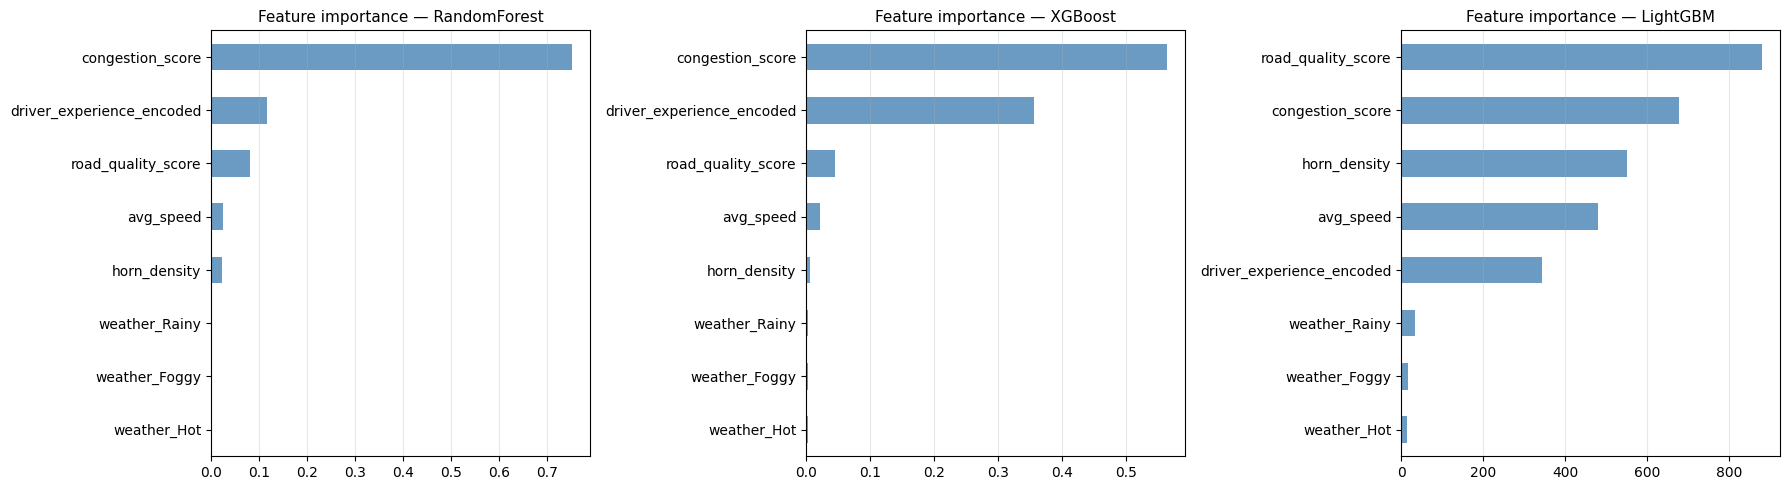

In [12]:
# Feature importance 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, ["RandomForest", "XGBoost", "LightGBM"]):
    importances = pd.Series(
        models[name].feature_importances_,
        index=X_train_boost.columns
    ).sort_values(ascending=True)

    importances.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
    ax.set_title(f'Feature importance — {name}', fontsize=11)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("../results/figures/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

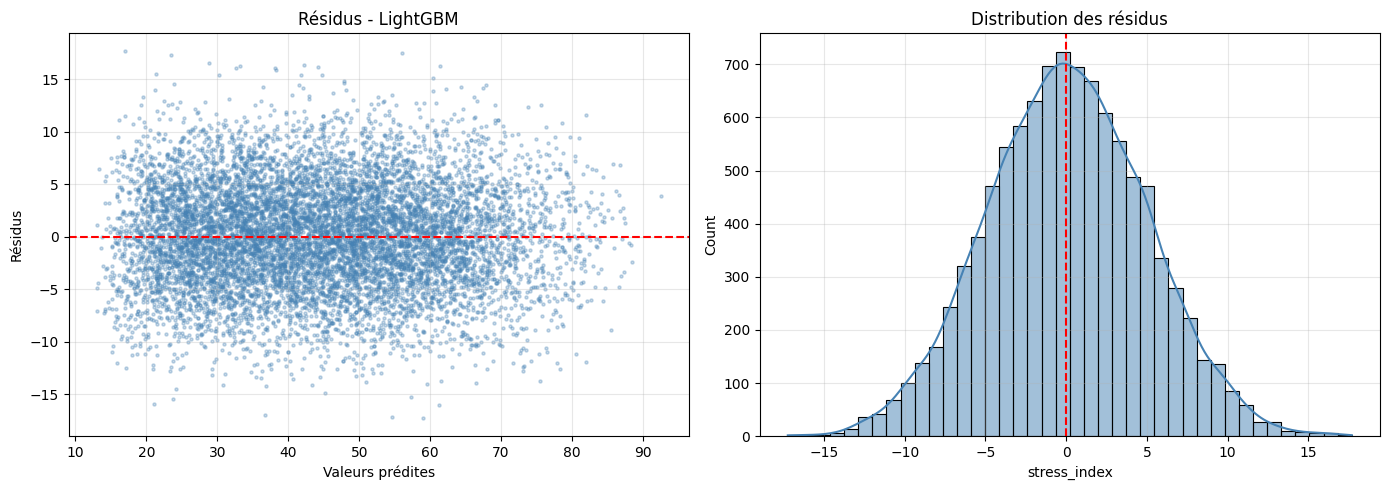

In [13]:
# Best model according R2
best_name  = df_results.index[0]
y_pred_best = results[best_name]["y_pred"]
y_test_best = results[best_name]["y_test"]
residuals   = y_test_best - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.3, color='steelblue', s=5)
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel("Valeurs prédites")
axes[0].set_ylabel("Résidus")
axes[0].set_title(f"Résidus - {best_name}")
axes[0].grid(alpha=0.3)

sns.histplot(residuals, kde=True, ax=axes[1], color='steelblue', bins=40)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title("Distribution des résidus")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../results/figures/residuals.png", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Let's save the best model
with open(f"../models/best_model_{best_name.lower()}.pkl", "wb") as f:
    pickle.dump(models[best_name], f)
    
# Save the scaler to apply it on new data before prediction
with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
    
print("scaler.pkl sauvegardé.")
print(f"\nMeilleur modèle : {best_name}")
print(f"R²={results[best_name]['R²']:.4f} | RMSE={results[best_name]['RMSE']:.3f} | MAE={results[best_name]['MAE']:.3f}")

scaler.pkl sauvegardé.

Meilleur modèle : LightGBM
R²=0.9086 | RMSE=4.913 | MAE=3.930


### Tuning phase

In [15]:
# Define parameters grids
param_grids = {
    "RandomForest": {
        "n_estimators"    : randint(100, 500),
        "max_depth"       : randint(5, 20),
        "min_samples_leaf": randint(2, 20),
        "max_features"    : ["sqrt", "log2", 0.5],
    },
    "XGBoost": {
        "n_estimators"    : randint(100, 600),
        "learning_rate"   : uniform(0.01, 0.2),
        "max_depth"       : randint(3, 10),
        "subsample"       : uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.6, 0.4),
    },
    "LightGBM": {
        "n_estimators"    : randint(100, 600),
        "learning_rate"   : uniform(0.01, 0.15),
        "max_depth"       : randint(4, 12),
        "num_leaves"      : randint(20, 100),
        "min_child_samples": randint(10, 50),
        "subsample"       : uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.6, 0.4),
    }
}

In [16]:
# Tuning 
# KFold for the cross validation 
cv = KFold(n_splits=5, shuffle=True, random_state=42)

base_models = {
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "XGBoost"     : XGBRegressor(random_state=42, verbosity=0),
    "LightGBM"    : LGBMRegressor(random_state=42, verbose=-1),
}

best_models  = {}
tuning_results = {}

for name, model in base_models.items():
    print(f"\n=== Tuning {name} ===")
    search = RandomizedSearchCV(
        estimator   = model,
        param_distributions = param_grids[name],
        n_iter      = 30,          
        scoring     = "r2",
        cv          = cv,
        random_state= 42,
        n_jobs      = -1,
        verbose     = 1
    )
    search.fit(X_train_boost, y_train_boost)

    best_models[name] = search.best_estimator_
    tuning_results[name] = {
        "best_params" : search.best_params_,
        "cv_r2"       : search.best_score_,
    }
    print(f"Meilleurs params : {search.best_params_}")
    print(f"R² CV moyen      : {search.best_score_:.4f}")


=== Tuning RandomForest ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleurs params : {'max_depth': 17, 'max_features': 0.5, 'min_samples_leaf': 14, 'n_estimators': 164}
R² CV moyen      : 0.9085

=== Tuning XGBoost ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleurs params : {'colsample_bytree': np.float64(0.7599443886861021), 'learning_rate': np.float64(0.019333132642723086), 'max_depth': 6, 'n_estimators': 563, 'subsample': np.float64(0.6931085361721216)}
R² CV moyen      : 0.9097

=== Tuning LightGBM ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleurs params : {'colsample_bytree': np.float64(0.9637281608315128), 'learning_rate': np.float64(0.04881699724000254), 'max_depth': 11, 'min_child_samples': 13, 'n_estimators': 101, 'num_leaves': 25, 'subsample': np.float64(0.6831766651472755)}
R² CV moyen      : 0.9095


In [17]:
# Overfitting verification
print("\n=== Vérification overfitting après tuning ===\n")
for name, model in best_models.items():
    r2_train = r2_score(y_train_boost, model.predict(X_train_boost))
    r2_test  = tuning_results[name]["cv_r2"]
    gap      = r2_train - r2_test
    flag     = "overfit" if gap > 0.05 else "ok"
    print(f"{name:20s} | R² train={r2_train:.4f} | R² test={r2_test:.4f} | gap={gap:.4f} {flag}")


=== Vérification overfitting après tuning ===

RandomForest         | R² train=0.9276 | R² test=0.9085 | gap=0.0191 ok
XGBoost              | R² train=0.9203 | R² test=0.9097 | gap=0.0106 ok
LightGBM             | R² train=0.9138 | R² test=0.9095 | gap=0.0042 ok


In [18]:
# Evaluation before and after tuning
print("\n=== Comparaison avant / après tuning ===\n")
print(f"{'Modèle':20s} | {'R² avant':>10} | {'R² après':>10} | {'RMSE avant':>12} | {'RMSE après':>12} | {'Gain':>8}")
print("-" * 85)

tuned_results = {}
for name, model in best_models.items():
    y_pred_tuned = model.predict(X_test_boost)

    r2_avant  = results[name]["R²"]
    r2_apres  = r2_score(y_test_boost, y_pred_tuned)
    rmse_avant= results[name]["RMSE"]
    rmse_apres= np.sqrt(mean_squared_error(y_test_boost, y_pred_tuned))
    mae_apres = mean_absolute_error(y_test_boost, y_pred_tuned)
    gain      = r2_apres - r2_avant

    tuned_results[name] = {
        "RMSE"  : rmse_apres,
        "MAE"   : mae_apres,
        "R²"    : r2_apres,
        "y_pred": y_pred_tuned
    }
    print(f"{name:20s} | {r2_avant:>10.4f} | {r2_apres:>10.4f} | "
          f"{rmse_avant:>12.3f} | {rmse_apres:>12.3f} | {gain:>+8.4f}")


=== Comparaison avant / après tuning ===

Modèle               |   R² avant |   R² après |   RMSE avant |   RMSE après |     Gain
-------------------------------------------------------------------------------------
RandomForest         |     0.9019 |     0.9077 |        5.088 |        4.937 |  +0.0058
XGBoost              |     0.9045 |     0.9090 |        5.022 |        4.902 |  +0.0045
LightGBM             |     0.9086 |     0.9085 |        4.913 |        4.915 |  -0.0001


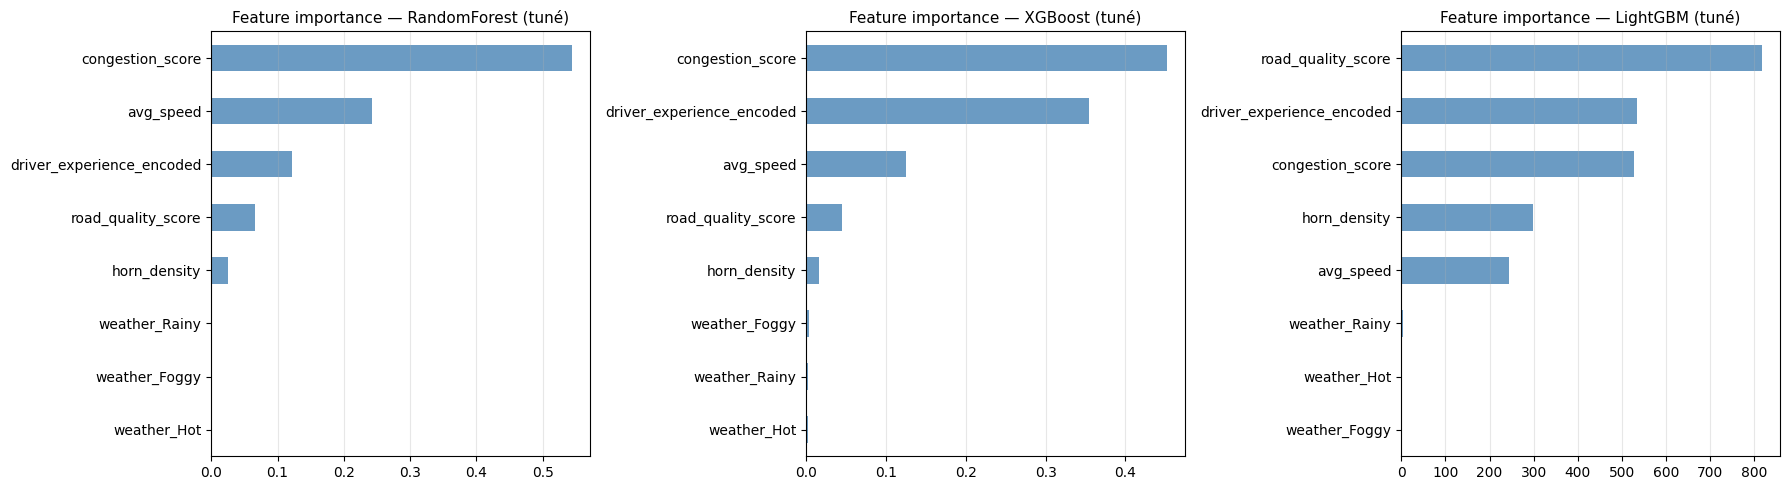

In [19]:
# Feature importance after tuning
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, ["RandomForest", "XGBoost", "LightGBM"]):
    importances = pd.Series(
        best_models[name].feature_importances_,
        index=X_train_boost.columns
    ).sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
    ax.set_title(f'Feature importance — {name} (tuné)', fontsize=11)
    ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figures/feature_importance_tuned.png", dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Best model after tuning
best_tuned_name = max(tuned_results, key=lambda k: tuned_results[k]["R²"])
y_pred_best     = tuned_results[best_tuned_name]["y_pred"]
residuals       = y_test_boost - y_pred_best

print(f"Meilleur modèle après tuning : {best_tuned_name}")
print(f"R²={tuned_results[best_tuned_name]['R²']:.4f} | "
      f"RMSE={tuned_results[best_tuned_name]['RMSE']:.3f} | "
      f"MAE={tuned_results[best_tuned_name]['MAE']:.3f}")

Meilleur modèle après tuning : XGBoost
R²=0.9090 | RMSE=4.902 | MAE=3.927


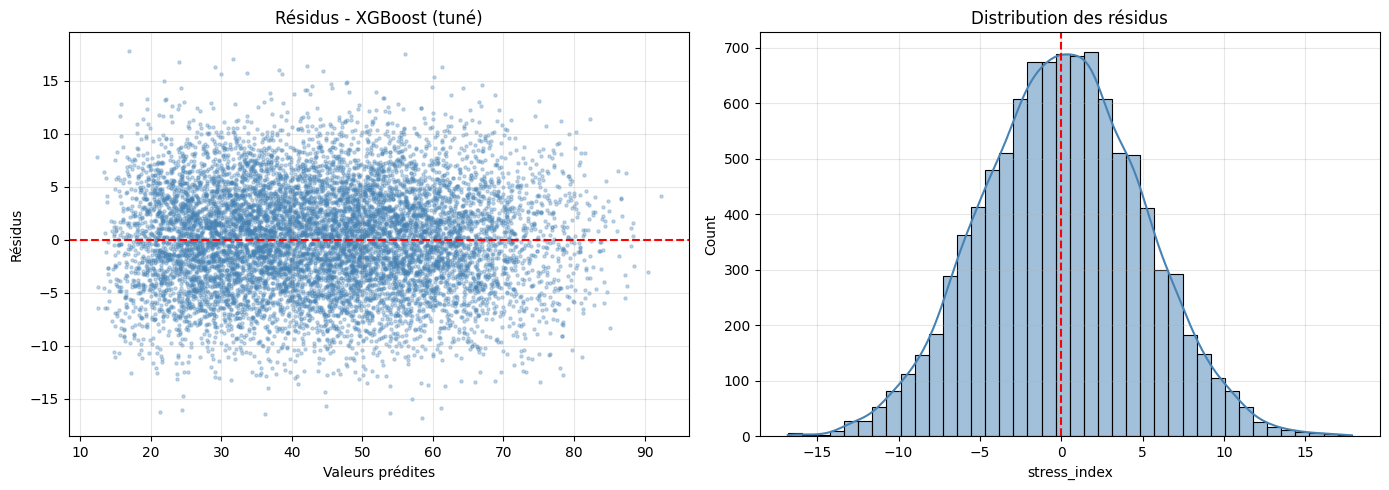

In [21]:
# Residue visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.3, color='steelblue', s=5)
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel("Valeurs prédites")
axes[0].set_ylabel("Résidus")
axes[0].set_title(f"Résidus - {best_tuned_name} (tuné)")
axes[0].grid(alpha=0.3)

sns.histplot(residuals, kde=True, ax=axes[1], color='steelblue', bins=40)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title("Distribution des résidus")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../results/figures/residuals_tuned.png", dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Final Table
final_summary = pd.DataFrame({
    "LinearRegression" : {"RMSE": results["LinearRegression"]["RMSE"],
                          "MAE" : results["LinearRegression"]["MAE"],
                          "R²"  : results["LinearRegression"]["R²"],
                          "Tuné": "Non"},
    **{f"{n} (tuné)": {"RMSE": tuned_results[n]["RMSE"],
                        "MAE" : tuned_results[n]["MAE"],
                        "R²"  : tuned_results[n]["R²"],
                        "Tuné": "Oui"}
       for n in tuned_results}
}).T.sort_values("R²", ascending=False)

print("=== TABLEAU FINAL ===")
print(final_summary.round(4))

=== TABLEAU FINAL ===
                         RMSE       MAE        R² Tuné
XGBoost (tuné)       4.902149   3.92654  0.908952  Oui
LightGBM (tuné)      4.914892  3.936848  0.908478  Oui
RandomForest (tuné)  4.936724  3.951867  0.907663  Oui
LinearRegression     6.106949  4.871222  0.858699  Non


In [23]:
# Let's save the best model and best params find after tuning
with open(f"../models/best_model_tuned_{best_tuned_name.lower()}.pkl", "wb") as f:
    pickle.dump(best_models[best_tuned_name], f)

with open("../models/best_params.pkl", "wb") as f:
    pickle.dump(tuning_results, f)

print(f"Modèle sauvegardé : best_model_tuned_{best_tuned_name.lower()}.pkl")
print("\nMeilleurs paramètres trouvés :")
for name, res in tuning_results.items():
    print(f"\n{name} :")
    for k, v in res["best_params"].items():
        print(f"  {k}: {v}")

Modèle sauvegardé : best_model_tuned_xgboost.pkl

Meilleurs paramètres trouvés :

RandomForest :
  max_depth: 17
  max_features: 0.5
  min_samples_leaf: 14
  n_estimators: 164

XGBoost :
  colsample_bytree: 0.7599443886861021
  learning_rate: 0.019333132642723086
  max_depth: 6
  n_estimators: 563
  subsample: 0.6931085361721216

LightGBM :
  colsample_bytree: 0.9637281608315128
  learning_rate: 0.04881699724000254
  max_depth: 11
  min_child_samples: 13
  n_estimators: 101
  num_leaves: 25
  subsample: 0.6831766651472755


### **Conclusion**

 **RÉSULTATS AVANT TUNING**   
  LinearRegression  R²=0.8587 | RMSE=6.107 | MAE=4.871  (benchmark)  
  RandomForest      R²=0.9019 | RMSE=5.088 | MAE=4.078  (overfit gap=0.084)  
  XGBoost           R²=0.9045 | RMSE=5.022 | MAE=4.017  
  LightGBM          R²=0.9086 | RMSE=4.913 | MAE=3.930  

 **RÉSULTATS APRÈS TUNING (RandomizedSearchCV 30 iter × 5 folds)**   
  RandomForest tuné R²=0.9077 | RMSE=4.937 | gap overfitting corrigé   
  LightGBM tuné     R²=0.9085 | RMSE=4.915 | perte négligeable (-0.0001)  
  **XGBoost tuné**     R²=0.9090 | RMSE=4.902 | MAE=3.927  <- **MEILLEUR MODÈLE**  

 **OBSERVATIONS CLÉS**   
  • RandomForest overfittait (gap=0.084) -> corrigé par min_samples_leaf=14  
  • LightGBM par défaut était déjà bien calibré — tuning sans bénéfice  
  • XGBoost bénéficie le plus du tuning (+0.0045 de R²)  
  • Gain global du tuning modeste (+0.004) : dataset bien structuré  

 **MODÈLE RETENU**   
  XGBoost tuné - R²=0.9090 | RMSE=4.902 | MAE=3.927  
  Sauvegardé : ../models/best_model_tuned_xgboost.pkl  
  Paramètres : n_estimators=563, lr=0.019, max_depth=6, subsample=0.693, colsample_bytree=0.760  
 
 **INTERPRÉTATION**   
  Le modèle explique 90.9% de la variance du stress index.  
  La régression linéaire (R²=0.859) confirme que la relation 
  est majoritairement linéaire - les arbres capturent
  les 5% de variance non-linéaire restants.